In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
from sklearn.datasets import make_blobs

In [3]:
x,y=make_blobs(n_features=2,n_samples=1000,centers=3,random_state=23)

In [4]:
x.shape

(1000, 2)

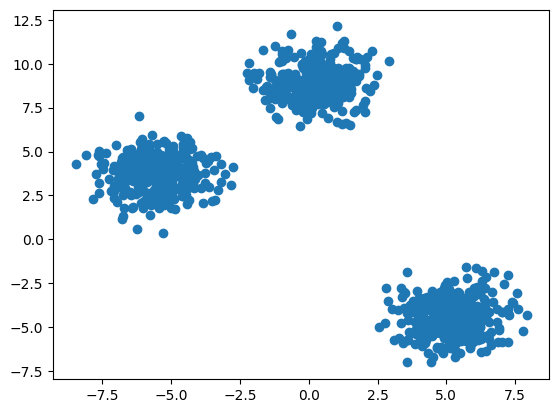

In [5]:
plt.scatter(x[:,0],x[:,1])

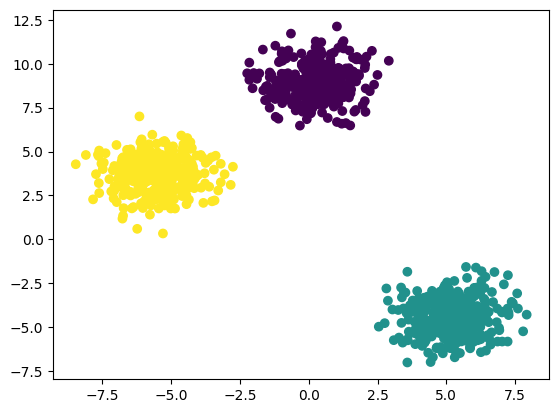

In [6]:
# we ignore y part
plt.scatter(x[:,0],x[:,1],c=y)

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.33)

In [8]:
from sklearn.cluster import KMeans

In [9]:
##Manual Process
##Elbow to select the k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [10]:
wcss

[34827.57682552022,
 7935.4372861454185,
 1319.2730531585607,
 1170.8897772037394,
 993.3036779977673,
 853.7528135404276,
 911.3341839663682,
 680.1503547172899,
 640.2261383983292,
 569.1202556304263]

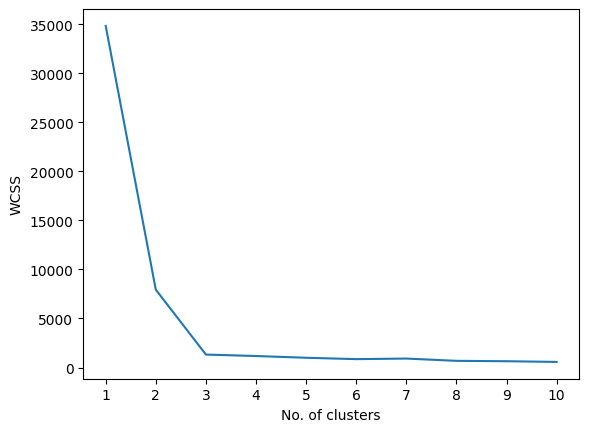

In [11]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("No. of clusters")
plt.ylabel('WCSS')
plt.show()

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
y_labels=kmeans.fit_predict(x_train)

In [19]:
y_test_label=kmeans.predict(x_test)

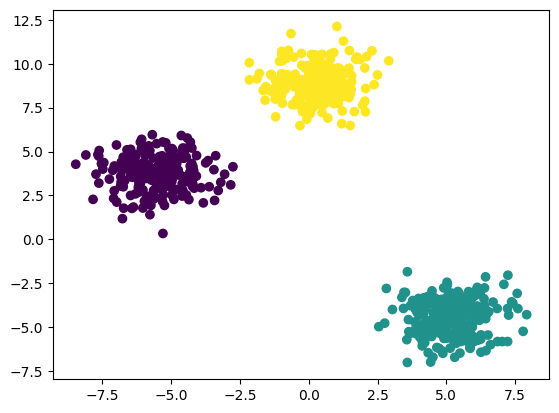

In [20]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_labels)

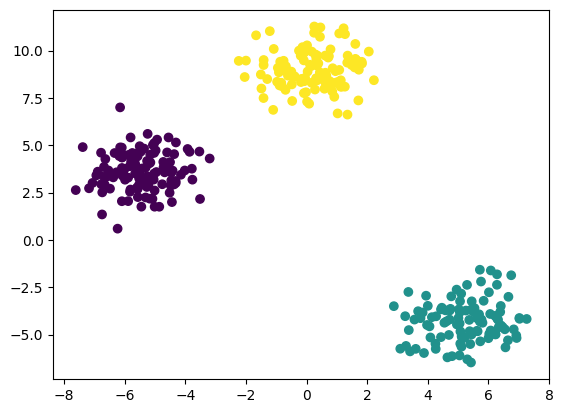

In [21]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_label)


In [22]:
##knee locator
!pip install kneed

In [25]:
from kneed import KneeLocator

In [27]:
k1=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')


In [28]:
k1.elbow

np.int64(3)

In [32]:
##Performnace matrix
##slihoutte score
from sklearn.metrics import silhouette_score

In [33]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)
    
    


In [34]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6433169469265496,
 0.4895647834796006,
 0.3378792123187683,
 0.3350630255718385,
 0.4959121818415387,
 0.34435172141998177,
 0.3409909915179289]

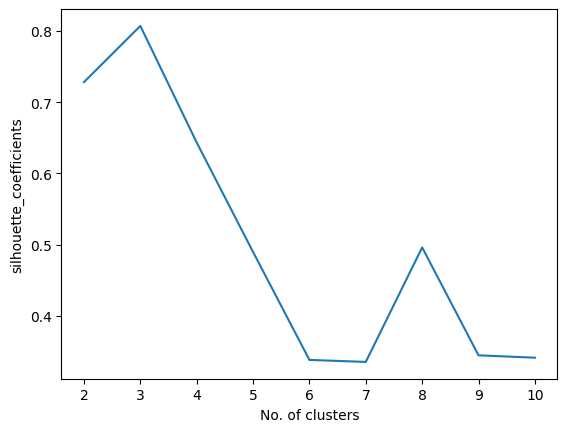

In [35]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("No. of clusters")
plt.ylabel('silhouette_coefficients')
plt.show()